# Pulsed vs Continuous Plasma Control — Demo

This notebook compares **pulse-based** vs **constant power** control across
multiple physics regimes. The model includes a resolution scale ℓ(t) that
mediates both barrier washout and observation noise.

**Key result:** In ~40% of regimes (from stage B autosearch), pulsed control achieves both **lower energy cost**
and **better tracking** than the best constant controller.

**Setup:** `pip install -r requirements.txt` (from `plasma_pulse_opt`). **Runtime: ~5 min.** For full autosearch, see `run.py` and `run_comparison.py`.


In [1]:
import sys, os, numpy as np
sys.path.insert(0, os.path.abspath("."))

from src.physics_sampling import params_from_sample
from src.simulate import run_simulation, choose_dt
from src.controllers import make_constant, make_pulse_train, make_kick_hold
from src.metrics import compute_metrics

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 1. Physics regime & degradation handles

All parameters are exposed here — tweak and re-run to explore.

In [2]:
# --- Winning regimes (pulse beats constant in these) ------------------------------—
WINNING_REGIMES = {
    "Pulse-friendly": {
        "tau0": 1.0, "tauB": 8.0, "kappa": 8.0, "eta": 0.6, "beta": 0.001,
        "gamma_wash": 0.4, "lambda_wash": 0.8,
        "P_hold_frac": 0.05, "tau_decay_frac": 0.8,
        "W_on": 0.9, "W_off": 0.6, "P_on_frac": 0.5, "P_off_frac": 0.08,
        "alpha_ell": 1.5, "tau_ell_frac": 0.3, "beta_ell": 0.1,
    },
    "Moderate barrier": {
        "tau0": 1.0, "tauB": 6.0, "kappa": 8.0, "eta": 0.7, "beta": 0.002,
        "gamma_wash": 0.35, "lambda_wash": 0.6,
        "P_hold_frac": 0.06, "tau_decay_frac": 0.6,
        "W_on": 0.9, "W_off": 0.6, "P_on_frac": 0.45, "P_off_frac": 0.08,
        "alpha_ell": 1.0, "tau_ell_frac": 0.5, "beta_ell": 0.08,
    },
    "High washout": {
        "tau0": 1.5, "tauB": 2.0, "kappa": 3.0, "eta": 0.7, "beta": 0.005,
        "gamma_wash": 1.5, "lambda_wash": 2.0,
        "P_hold_frac": 0.15, "tau_decay_frac": 0.15,
        "W_on": 1.1, "W_off": 0.8, "P_on_frac": 0.4, "P_off_frac": 0.25,
        "alpha_ell": 2.5, "tau_ell_frac": 0.2, "beta_ell": 0.2,
    },
    "Balanced": {
        "tau0": 1.0, "tauB": 5.0, "kappa": 6.0, "eta": 0.55, "beta": 0.002,
        "gamma_wash": 0.5, "lambda_wash": 1.0,
        "P_hold_frac": 0.08, "tau_decay_frac": 0.5,
        "W_on": 0.9, "W_off": 0.6, "P_on_frac": 0.45, "P_off_frac": 0.10,
        "alpha_ell": 1.2, "tau_ell_frac": 0.4, "beta_ell": 0.12,
    },
}

# SAMPLE: regime for Pareto & time-series (must have feasible points)
# WINNING_REGIMES: example regimes; bar chart (section 2.5) loads top results from stage_b CSV
SAMPLE = {
    "tau0": 1.0, "tauB": 8.0, "kappa": 8.0, "eta": 0.6, "beta": 0.001,
    "gamma_wash": 0.05, "lambda_wash": 0.8,
    "P_hold_frac": 0.05, "tau_decay_frac": 0.8,
    "W_on": 0.9, "W_off": 0.6, "P_on_frac": 0.5, "P_off_frac": 0.08,
    "alpha_ell": 0.5, "tau_ell_frac": 0.1, "beta_ell": 0.1,
}

# --- Degradation (set all to 0 for ideal conditions) ---------------------------------
DEGRADATION = {
    "tau_actuator": 0.05,    # actuator lag time constant
    "sigma_W_base": 0.02,   # baseline measurement noise on W
    "p_elm": 0.5,           # ELM crash probability per unit time
    "elm_crash_frac": 0.3,  # fraction of B lost per ELM
}

# --- Simulation settings ------------------------------------------------------------------------------
P_MAX = 1.0
T_TOTAL = 30.0
W_TARGET = 1.0
W_MIN_FRAC = 0.9
FEASIBILITY_TOL = 0.20  # max fraction of time W < W_min (feasible)

print(f"Physics: tau0={SAMPLE['tau0']}, tauB={SAMPLE['tauB']}, kappa={SAMPLE['kappa']}")
print(f"Resolution: alpha_ell={SAMPLE['alpha_ell']}, tau_ell_frac={SAMPLE['tau_ell_frac']}, beta_ell={SAMPLE['beta_ell']}")
print(f"Degradation: tau_act={DEGRADATION['tau_actuator']}, noise={DEGRADATION['sigma_W_base']}, p_elm={DEGRADATION['p_elm']}")


Physics: tau0=1.0, tauB=8.0, kappa=8.0
Resolution: alpha_ell=0.5, tau_ell_frac=0.1, beta_ell=0.1
Degradation: tau_act=0.05, noise=0.02, p_elm=0.5


## 2. Sweep controllers

We test constant power levels, pulse trains, and kick-hold patterns.
Each is run under both **clean** and **degraded** conditions.

In [3]:
CONST_LEVELS = np.linspace(0.05, 1.0, 25)

PULSE_GRID = [
    (pb, dp, per, d)
    for pb in [0.03, 0.05, 0.1, 0.15, 0.2, 0.3]
    for dp in [0.3, 0.5, 0.7, 0.9]
    for per in [0.3, 0.5, 1.0, 2.0]
    for d in [0.1, 0.2, 0.3, 0.5]
    if pb + dp <= 1.01
]

KICK_GRID = [
    (pk, tk, ph, per)
    for pk in [0.5, 0.7, 1.0]
    for tk in [0.05, 0.1, 0.2, 0.5]
    for ph in [0.03, 0.05, 0.1, 0.2]
    for per in [0.5, 1.0, 2.0]
]

print(f"Controllers: {len(CONST_LEVELS)} constant, {len(PULSE_GRID)} pulse, {len(KICK_GRID)} kick")
print(f"Total per condition: {len(CONST_LEVELS) + len(PULSE_GRID) + len(KICK_GRID)}")

Controllers: 25 constant, 336 pulse, 144 kick
Total per condition: 505


In [4]:
import time

def run_sweep(sample, extra=None, label=""):
    merged = {**sample, "noise_seed": 42}
    if extra:
        merged.update(extra)
    params = params_from_sample(merged, P_MAX)
    dt = choose_dt(params["tau0"], params["tauB"], params.get("tau_ell", 1.0))
    ell0 = params.get("ell0", 0.0)
    t0 = time.time()

    results = {"const": [], "pulse": [], "kick": []}
    best = {"const": (None, 1e9), "pulse": (None, 1e9), "kick": (None, 1e9)}

    for P_frac in CONST_LEVELS:
        ctrl = make_constant(P_frac * P_MAX, P_MAX)
        t, W, B, ell, P = run_simulation(ctrl, T_TOTAL, dt, params)
        m = compute_metrics(t, W, B, ell, P, W_TARGET, W_MIN_FRAC, ell0=ell0)
        if m["time_below"] <= FEASIBILITY_TOL:
            results["const"].append((m["avg_power"], m["tracking_error"]))
            if m["tracking_error"] < best["const"][1]:
                best["const"] = ((t, W, B, ell, P, m), m["tracking_error"])

    ERR_TARGET_TOL = 1.15  # pulse/kick must have error <= const * this
    err_target = best["const"][1] * ERR_TARGET_TOL if best["const"][0] else 1e9

    for pb, dp, per, d in PULSE_GRID:
        ctrl = make_pulse_train(pb * P_MAX, dp * P_MAX, per, d, P_MAX)
        t, W, B, ell, P = run_simulation(ctrl, T_TOTAL, dt, params)
        m = compute_metrics(t, W, B, ell, P, W_TARGET, W_MIN_FRAC, ell0=ell0)
        if m["time_below"] <= FEASIBILITY_TOL:
            results["pulse"].append((m["avg_power"], m["tracking_error"]))
            if (m["tracking_error"] <= err_target or best["pulse"][0] is None) and m["avg_power"] < best["pulse"][1]:
                best["pulse"] = ((t, W, B, ell, P, m), m["avg_power"])

    for pk, tk, ph, per in KICK_GRID:
        ctrl = make_kick_hold(pk * P_MAX, tk, ph * P_MAX, per, P_MAX)
        t, W, B, ell, P = run_simulation(ctrl, T_TOTAL, dt, params)
        m = compute_metrics(t, W, B, ell, P, W_TARGET, W_MIN_FRAC, ell0=ell0)
        if m["time_below"] <= FEASIBILITY_TOL:
            results["kick"].append((m["avg_power"], m["tracking_error"]))
            if (m["tracking_error"] <= err_target or best["kick"][0] is None) and m["avg_power"] < best["kick"][1]:
                best["kick"] = ((t, W, B, ell, P, m), m["avg_power"])

    elapsed = time.time() - t0
    nc, np_, nk = len(results["const"]), len(results["pulse"]), len(results["kick"])
    print(f"  {label}: const={nc}  pulse={np_}  kick={nk}  ({elapsed:.0f}s)")
    return results, {k: v[0] for k, v in best.items()}

print("Running clean...")
res_clean, best_clean = run_sweep(SAMPLE, label="Clean")
print("Running degraded...")
res_deg, best_deg = run_sweep(SAMPLE, DEGRADATION, label="Degraded")
print("Done!")


Running clean...
  Clean: const=13  pulse=21  kick=15  (132s)
Running degraded...
  Degraded: const=13  pulse=23  kick=15  (146s)
Done!


## 2.5 Pulse advantage across regimes

Power savings when using the best pulse vs best constant controller. Positive = pulse wins. **Run from plasma_pulse_opt.** Bar chart uses pre-generated CSVs — create them with `python run.py --stage AB --N_phys 200` (or reuse existing `results/clean/` and `results/degraded/`).

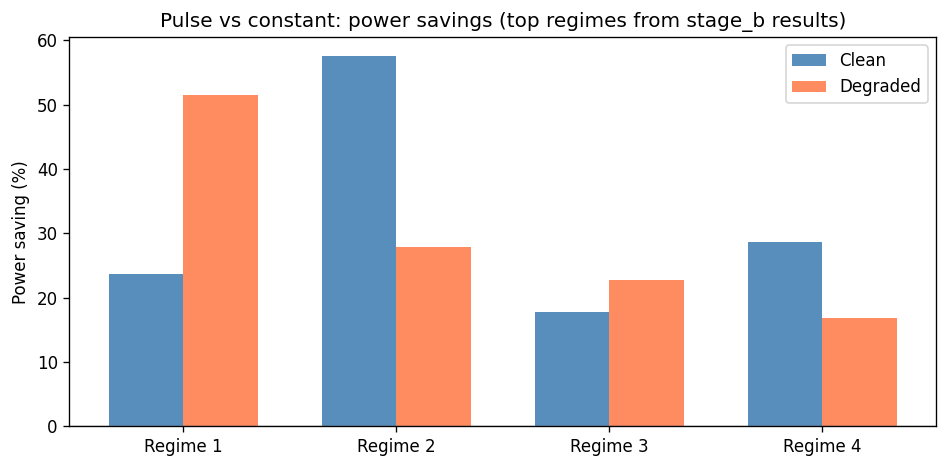

In [5]:
# Load precomputed results from stage_b autosearch (no simulation)
import pandas as pd

def load_savings(csv_path, n=4):
    if not os.path.exists(csv_path):
        print(f"Warning: {csv_path} not found. Run from plasma_pulse_opt. Bar chart will be empty.")
        return np.array([]), np.array([])
    df = pd.read_csv(csv_path)
    wins = df[df["pulsing_wins"] == True].copy()
    wins["saving"] = (wins["best_baseline_avg_power"] - wins["best_pulse_avg_power"]) / wins["best_baseline_avg_power"] * 100
    wins = wins.nlargest(n, "improvement")
    return wins["saving"].values, wins["improvement"].values

clean_sav, clean_imp = load_savings("results/clean/stage_b_results.csv")
deg_sav, deg_imp = load_savings("results/degraded/stage_b_results.csv")
n = min(4, len(clean_sav), len(deg_sav))
if n == 0:
    n = 1
    labels = ["No data"]
else:
    labels = [f"Regime {i+1}" for i in range(n)]
clean_vals = clean_sav[:n] if len(clean_sav) >= n else list(clean_sav) + [0] * (n - len(clean_sav))
deg_vals = deg_sav[:n] if len(deg_sav) >= n else list(deg_sav) + [0] * (n - len(deg_sav))

x = np.arange(n)
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, clean_vals[:n], w, label="Clean", color="steelblue", alpha=0.9)
ax.bar(x + w/2, deg_vals[:n], w, label="Degraded", color="coral", alpha=0.9)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylabel("Power saving (%)")
ax.set_title("Pulse vs constant: power savings (top regimes from stage_b results)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Pareto clouds

Each dot is one controller configuration. **Lower-left is better** (less power, less error).
The blue step line is the constant-controller frontier: points **left of it** (same error, less power) = pulse wins.

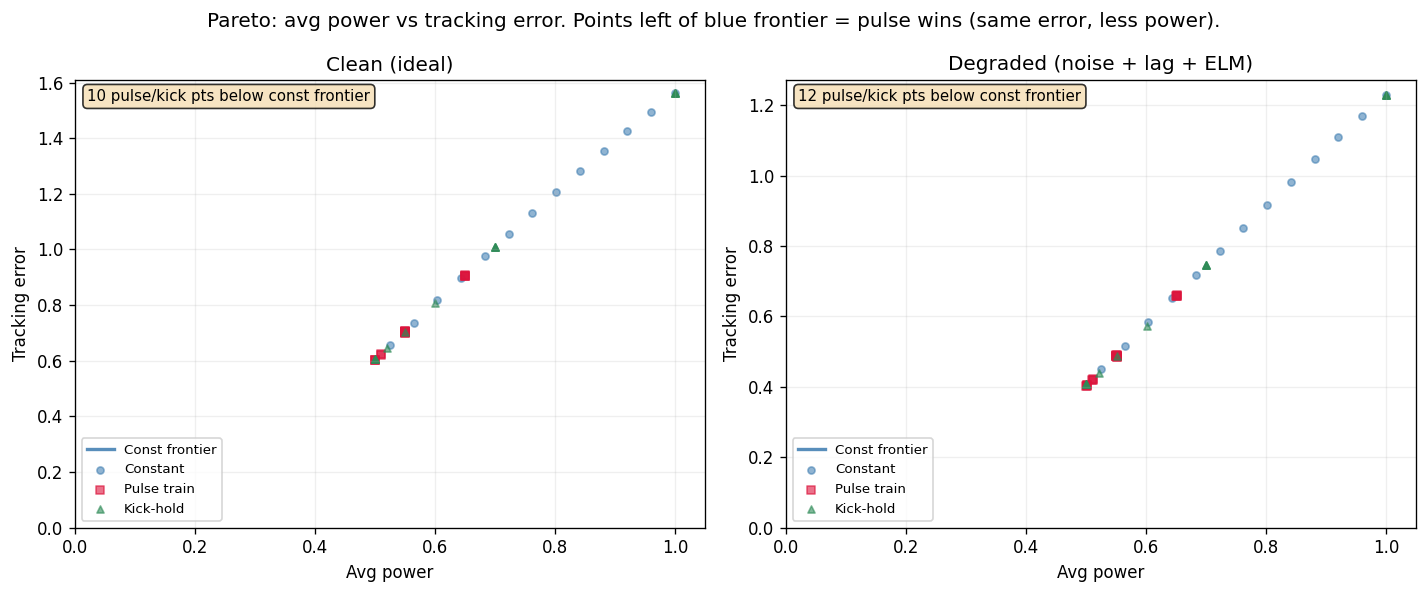

In [6]:
def build_const_frontier(pts):
    """Pareto frontier of constant: min power for each error level."""
    if not pts:
        return [], []
    sorted_pts = sorted(pts, key=lambda x: x[1])  # by error
    frontier_p, frontier_e = [], []
    min_p = 1e9
    for p, e in sorted_pts:
        if p < min_p:
            min_p = p
            frontier_p.append(p)
            frontier_e.append(e)
    return frontier_p, frontier_e

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, res, title in [(ax1, res_clean, "Clean (ideal)"),
                        (ax2, res_deg, "Degraded (noise + lag + ELM)")]:
    # Constant frontier (baseline to beat)
    fp, fe = build_const_frontier(res["const"])
    if fp:
        # Frontier: (power, error) — points left of it = pulse wins
        ax.step(fp, fe, where="post", color="steelblue", lw=2, alpha=0.9,
                label="Const frontier", zorder=5)
    # Scatter
    for pts, color, marker, label in [
        (res["const"], "steelblue", "o", "Constant"),
        (res["pulse"], "crimson", "s", "Pulse train"),
        (res["kick"], "seagreen", "^", "Kick-hold"),
    ]:
        if pts:
            xs, ys = zip(*pts)
            ax.scatter(xs, ys, c=color, s=18, alpha=0.6, marker=marker, label=label)
    # Count pulse wins: (p,e) wins if const needs more power to reach same error
    n_pulse_wins = 0
    if res["const"]:
        for pts in [res["pulse"], res["kick"]]:
            for p, e in pts:
                min_p_const = min((pc for pc, ec in res["const"] if ec <= e + 1e-6), default=1e9)
                if p < min_p_const - 1e-6:
                    n_pulse_wins += 1
    if n_pulse_wins > 0:
        ax.text(0.02, 0.98, f"{n_pulse_wins} pulse/kick pts below const frontier", transform=ax.transAxes,
                fontsize=9, va="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    ax.set_xlabel("Avg power")
    ax.set_ylabel("Tracking error")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.2)

fig.suptitle("Pareto: avg power vs tracking error. Points left of blue frontier = pulse wins (same error, less power).", fontsize=12)
fig.tight_layout()
plt.show()

## 4. Time-series: best controllers head-to-head

**Constant:** best quality (lowest tracking error). **Pulse/Kick:** lowest power among configs that match or beat const quality (error в‰¤ constГ—1.15). This gives a fair head-to-head at similar performance.

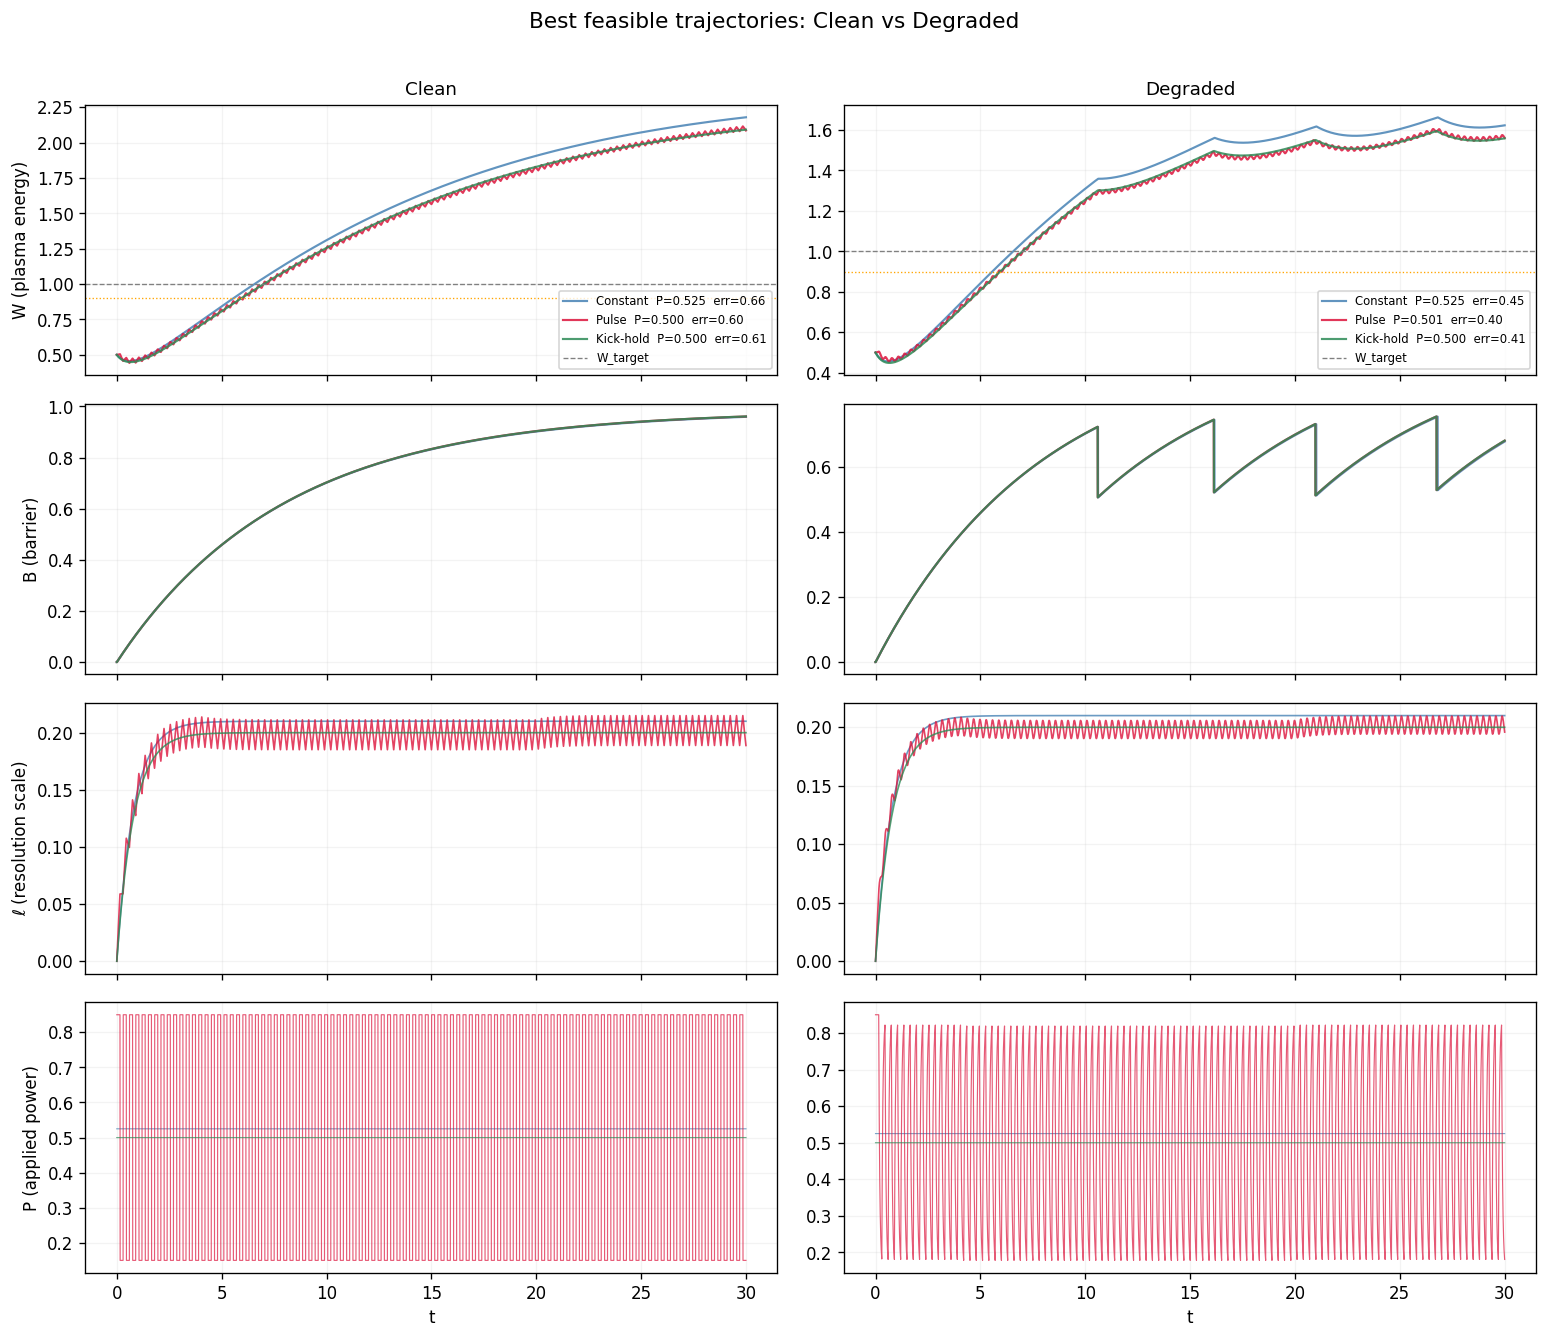

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(13, 11), sharex="col")
fig.suptitle("Best feasible trajectories: Clean vs Degraded", fontsize=13, y=1.01)

for col, (bests, title) in enumerate([(best_clean, "Clean"),
                                       (best_deg, "Degraded")]):
    for key, color, label in [("const", "steelblue", "Constant"),
                               ("pulse", "crimson", "Pulse"),
                               ("kick", "seagreen", "Kick-hold")]:
        data = bests[key]
        if data is None:
            continue
        t, W, B, ell_arr, P, m = data
        tag = f"{label}  P\u0304={m['avg_power']:.3f}  err={m['tracking_error']:.2f}"
        axes[0, col].plot(t, W, color=color, lw=1.3, alpha=0.85, label=tag)
        axes[1, col].plot(t, B, color=color, lw=1.3, alpha=0.85)
        axes[2, col].plot(t, ell_arr, color=color, lw=1.0, alpha=0.8)
        axes[3, col].plot(t, P, color=color, lw=0.7, alpha=0.7)

    axes[0, col].axhline(W_TARGET, ls="--", c="grey", lw=0.8, label="W_target")
    axes[0, col].axhline(W_MIN_FRAC * W_TARGET, ls=":", c="orange", lw=0.8)
    axes[0, col].set_title(title, fontsize=11)
    axes[0, col].legend(fontsize=7, loc="lower right")
    axes[3, col].set_xlabel("t")

for row, ylabel in enumerate(["W (plasma energy)", "B (barrier)",
                               "\u2113 (resolution scale)", "P (applied power)"]):
    axes[row, 0].set_ylabel(ylabel)
    for c in range(2):
        axes[row, c].grid(True, alpha=0.15)

fig.tight_layout()
plt.show()


## 5. Power savings summary

How much power does pulsed control save vs the best constant controller?

In [8]:
# Power savings: see bar chart (section 2.5) for regime-level comparison from stage_b.
# Time-series above shows head-to-head for SAMPLE regime.
import pandas as pd
for name, path in [("Clean", "results/clean/stage_b_results.csv"), ("Degraded", "results/degraded/stage_b_results.csv")]:
    if os.path.exists(path):
        df = pd.read_csv(path)
        wins = (df["pulsing_wins"] == True).sum() if "pulsing_wins" in df.columns else 0
        print(f"{name}: {wins} regimes where pulse wins (of {len(df)})")


Clean: 22 regimes where pulse wins (of 54)
Degraded: 21 regimes where pulse wins (of 50)
